# Day 17 — Class imbalance

How lopsided are the classes, and do the usual mitigations (class weights, threshold shifting) change anything? Parameters come from Day 16. Validation set only; test set untouched.

In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score

from idxlab.clean import clean_ticker_data
from idxlab.config import load_config
from idxlab.data import DataLoader
from idxlab.evaluation import evaluate_classifier
from idxlab.logging_setup import setup_logging
from idxlab.split import build_dataset, time_based_split

Path("docs/results").mkdir(parents=True, exist_ok=True)

In [2]:
cfg = load_config()
setup_logging(cfg.log_level)

raw = DataLoader.from_config(cfg).load_all()
bbca = clean_ticker_data(raw["BBCA.JK"])

dataset = build_dataset(bbca, horizon=1)
splits = time_based_split(dataset, train_size=0.7, val_size=0.15)

LABEL_COLUMNS = ["forward_return", "direction"]
feature_cols = [c for c in dataset if c not in LABEL_COLUMNS]

assert len(feature_cols) == 12
assert not set(LABEL_COLUMNS) & set(feature_cols), "label bocor ke fitur!"

X_train, y_train = splits.train[feature_cols], splits.train["direction"].astype(int)
X_val, y_val = splits.val[feature_cols], splits.val["direction"].astype(int)

# Deliberately NOT using `dataset`: it contains the test rows, whose labels we have not looked at.
trainval = pd.concat([splits.train, splits.val])

21:52:13 | INFO     | idxlab.data | Cache hit for BBCA.JK (data\raw\BBCA_JK.parquet)
21:52:13 | INFO     | idxlab.data | Cache hit for BBRI.JK (data\raw\BBRI_JK.parquet)
21:52:13 | INFO     | idxlab.data | Cache hit for TLKM.JK (data\raw\TLKM_JK.parquet)
21:52:13 | INFO     | idxlab.data | Cache hit for ASII.JK (data\raw\ASII_JK.parquet)
21:52:13 | INFO     | idxlab.data | Cache hit for UNVR.JK (data\raw\UNVR_JK.parquet)


## 1. How imbalanced are the classes?

In [3]:

print("train:\n", y_train.value_counts(normalize=True).round(3))
print("val:\n", y_val.value_counts(normalize=True).round(3))

n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
print(f"\ntrain: {n_pos} up-days vs {n_neg} not-up days -> {max(n_pos, n_neg) / min(n_pos, n_neg):.2f} : 1")

train:
 direction
0    0.565
1    0.435
Name: proportion, dtype: float64
val:
 direction
0    0.598
1    0.402
Name: proportion, dtype: float64

train: 259 up-days vs 336 not-up days -> 1.30 : 1


In [4]:
# Is the up-share stable over time? (train + val only)
by_year = trainval["direction"].groupby(trainval.index.year).agg(up_share="mean", n_days="count")
by_year.round(3)

,up_share,n_days
date,,
2023,0.427,220
2024,0.456,237
2025,0.411,236
2026,0.379,29


In [5]:
majority = int(y_train.mean() > 0.5)
dummy_pred = np.full(len(y_val), majority)

print("majority-class accuracy on val:", round(accuracy_score(y_val, dummy_pred), 3))
print("balanced accuracy of the same dummy:", round(balanced_accuracy_score(y_val, dummy_pred), 3))

majority-class accuracy on val: 0.598
balanced accuracy of the same dummy: 0.5


## 2. Class weights

In [6]:
best = json.loads(Path("docs/results/day16_best_params.json").read_text(encoding="utf-8"))
pos_weight = n_neg / n_pos


def make_logreg(**kwargs):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, **kwargs)),
    ])


models = {
    "logreg | plain": make_logreg(),
    "logreg | weighted": make_logreg(class_weight="balanced"),
    "rf | plain": RandomForestClassifier(**best["rf"]),
    "rf | weighted": RandomForestClassifier(**best["rf"], class_weight="balanced"),
    "xgb | plain": XGBClassifier(**best["xgb"]),
    "xgb | weighted": XGBClassifier(**best["xgb"], scale_pos_weight=pos_weight),
}

In [7]:
rows = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]
    rows[name] = {
        **evaluate_classifier(y_val, pred, proba),
        "balanced_acc": balanced_accuracy_score(y_val, pred),
        "pr_auc": average_precision_score(y_val, proba),
        "pred_up_share": pred.mean(),
    }

mitigation = pd.DataFrame.from_dict(rows, orient="index").round(3)
mitigation[["accuracy", "balanced_acc", "precision", "recall", "f1", "roc_auc", "pr_auc", "pred_up_share"]]

,accuracy,balanced_acc,precision,recall,f1,roc_auc,pr_auc,pred_up_share
logreg | plain,0.583,0.522,0.458,0.216,0.293,0.571,0.484,0.189
logreg | weighted,0.583,0.555,0.477,0.412,0.442,0.571,0.485,0.346
rf | plain,0.449,0.504,0.404,0.784,0.533,0.547,0.529,0.780
rf | weighted,0.433,0.510,0.407,0.902,0.561,0.533,0.492,0.890
xgb | plain,0.543,0.551,0.448,0.588,0.508,0.582,0.498,0.528
xgb | weighted,0.535,0.567,0.451,0.725,0.556,0.587,0.511,0.646


## 3. Threshold shifting (threshold picked on train only)

In [8]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)


def oof_proba(model, X, y, cv):
    """Out-of-fold P(up): each row is predicted by a model that never saw it.

    cross_val_predict refuses TimeSeriesSplit (its test folds are not a partition
    of the data), so the loop is written by hand. The earliest rows are never in a
    test fold and are simply left out.
    """
    oof = pd.Series(np.nan, index=X.index)
    for tr, te in cv.split(X):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        oof.iloc[te] = m.predict_proba(X.iloc[te])[:, 1]
    return oof.dropna()


oof = oof_proba(models["xgb | plain"], X_train, y_train, tscv)
y_oof = y_train.loc[oof.index]
print(f"{len(oof)} of {len(X_train)} train rows have an out-of-fold prediction")

495 of 595 train rows have an out-of-fold prediction


best threshold on out-of-fold train predictions: 0.46


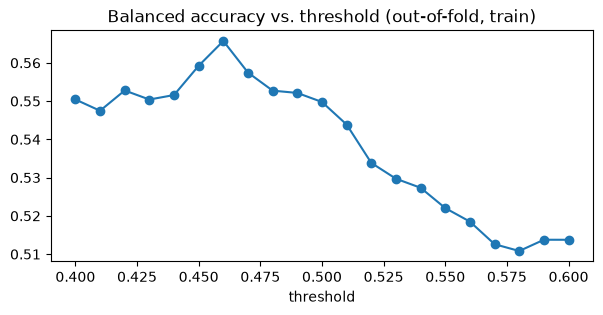

In [9]:
thresholds = np.round(np.arange(0.40, 0.61, 0.01), 2)
oof_scores = pd.Series(
    [balanced_accuracy_score(y_oof, (oof >= t).astype(int)) for t in thresholds],
    index=thresholds,
)

# TODO 7: threshold dengan balanced accuracy tertinggi (method Series yang mengembalikan LABEL indeksnya)
best_t = oof_scores.idxmax()
print(f"best threshold on out-of-fold train predictions: {best_t:.2f}")

ax = oof_scores.plot(marker="o", figsize=(7, 3), title="Balanced accuracy vs. threshold (out-of-fold, train)")
ax.set_xlabel("threshold")
plt.show()

In [10]:
val_proba = models["xgb | plain"].predict_proba(X_val)[:, 1]

rows = {}
for label, t in [("threshold 0.50", 0.50), (f"threshold {best_t:.2f} (from train OOF)", best_t)]:
    pred = (val_proba >= t).astype(int)
    rows[label] = {
        **evaluate_classifier(y_val, pred, val_proba),
        "balanced_acc": balanced_accuracy_score(y_val, pred),
        "pred_up_share": pred.mean(),
    }

threshold_table = pd.DataFrame.from_dict(rows, orient="index").round(3)
threshold_table

,accuracy,precision,recall,f1,roc_auc,balanced_acc,pred_up_share
threshold 0.50,0.543,0.448,0.588,0.508,0.582,0.551,0.528
threshold 0.46 (from train OOF),0.559,0.468,0.725,0.569,0.582,0.586,0.622


In [11]:
mitigation.to_csv("docs/results/day17_imbalance.csv")
threshold_table.to_csv("docs/results/day17_threshold.csv")